## Изучение алгоритма обратного распространения ошибки (метод Back Propagation)

In [491]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, List
np.random.seed(42)

### Класс НС Back Propagation

In [492]:
class BP_Neuron:
    def __init__(self, N: int, J: int, M: int, learning_rate: float = 1.0, eps: float = 1e-2):
        self.N = N
        self.J = J
        self.M = M
        self.learning_rate = learning_rate
        self.w1 = np.random.randn(self.J, self.N + 1) * 0.01
        self.w2 = np.random.randn(self.M, self.J + 1) * 0.01
        self.delta_history = []
        self.weight_history = []
        self.predict_history = []
        self.eps = eps
    
    def add_bias(self, x: np.ndarray) -> np.ndarray:
        return np.append(1.0, x)
    
    def get_net(self, weights: np.ndarray, x_bias: np.ndarray) -> float:
        return np.dot(weights, x_bias)
    
    def activate(self, net: float) -> float:
        return (1 - np.exp(-net)) / (1 + np.exp(-net))
    
    def activate_derivative(self, f_net: float) -> float:
        return 0.5 * (1 - f_net ** 2)
    
    def get_rmse(self, t: float, y: float) -> float:
        return np.sqrt(np.sum((t - y)**2))
    
    def forward(self, x: int) -> Tuple[float, ...]:
        x_bias = self.add_bias(x)
        
        net1 = self.get_net(self.w1, x_bias)
        out1 = self.activate(net1)
        out1_bias = self.add_bias(out1)
        
        net2 = self.get_net(self.w2, out1_bias)
        out2 = self.activate(net2)
        
        return x_bias, out1_bias, net2, out2
    
    def predict(self, x: np.ndarray) -> np.ndarray:
        _, _, _, out2 = self.forward(x)
        return out2
    
    def predict_batch(self, X: np.ndarray) -> np.ndarray:
        return np.array([self.predict(x) for x in X])
    
    def train_step(self, x: np.ndarray, t: np.ndarray) -> float:
        x_bias, out1_bias, net2, out2 = self.forward(x)
        
        delta2 = self.activate_derivative(out2) * (t - out2)
        delta1 = self.activate_derivative(out1_bias[1:]) * np.dot(self.w2[:, 1:].T, delta2)
        
        self.w2 += self.learning_rate * np.outer(delta2, out1_bias)
        self.w1 += self.learning_rate * np.outer(delta1, x_bias)
        
        return np.sum(np.abs(t - out2))
    
    def train_epoch(self, X: np.ndarray, y: np.ndarray) -> float:
        total_error = 0.0
        for i in range(len(X)):
            total_error += self.train_step(X[i], y[i])
        return total_error
    
    def train(self, X: np.ndarray, t: np.ndarray, max_epochs: int = 1000) -> None:
        self.targets = t.copy()
        self.delta_history = []
        self.weights_history = []
        self.predictions_history = []
        
        initial_predictions = self.predict_batch(X)
        initial_rmse = self.get_rmse(t, initial_predictions)
        
        self.delta_history.append(initial_rmse)
        self.weights_history.append({'w1': self.w1.copy(), 'w2': self.w2.copy()})
        self.predictions_history.append(initial_predictions.copy())
        
        for epoch in range(1, max_epochs + 1):
            self.train_epoch(X, t)
            predictions = self.predict_batch(X)
            rmse = self.get_rmse(t, predictions)
            self.delta_history.append(rmse)
            self.weights_history.append({'w1': self.w1.copy(), 'w2': self.w2.copy()})
            self.predictions_history.append(predictions.copy())
            
            if rmse <= self.eps:
                self.last_epoch = epoch + 1
                break
        else:
            self.last_epoch = max_epochs
            
    
    def print_training_info(self, X: np.ndarray) -> None:
        print(f"\n{'='*60}")
        print(f'Информация о МНС (архитектура {self.N}-{self.J}-{self.M})')
        print(f'Скорость обучения -> {self.learning_rate}')
        print(f'Образцов -> {len(X)}')
        print(f'Веса W1 (вход->скрытый):\n{self.w1}')
        print(f'Веса W2 (скрытый->выход):\n{self.w2}')
        if self.last_epoch > -1:
            print(f'Обучение завершено на эпохе -> {self.last_epoch}')
        else:
            print(f'Обучение ещё не проводилось или не было успешно завершено')
        print(f"{'='*60}\n")
        
    def get_weights_history(self) -> pd.DataFrame:
        if not self.weights_history:
            return pd.DataFrame()
        flat_weights_list = []
        for wh in self.weights_history:
            w1_flat = wh['w1'].flatten()
            w2_flat = wh['w2'].flatten()
            combined = np.concatenate([w1_flat, w2_flat])
            flat_weights_list.append(combined)
        col_names = []
        for j in range(self.J):
            for i in range(self.N + 1):
                col_names.append(f'w1_{j}_{i}')
        for m in range(self.M):
            for j in range(self.J + 1):
                col_names.append(f'w2_{m}_{j}')
                
        df = pd.DataFrame(flat_weights_list, columns=col_names)
        df['epoch'] = range(1, len(df) + 1)
        cols_order = ['epoch'] + col_names
        return df[cols_order]
    
    def get_outputs_table(self) -> pd.DataFrame:
        if not self.predictions_history:
            return pd.DataFrame()
        outputs_matrix = np.array(self.predictions_history)
        if outputs_matrix.ndim == 3:
            outputs_matrix = outputs_matrix[:, 0, :]
        n_epochs = outputs_matrix.shape[0]
        data = {'epoch': range(1, n_epochs + 1)}
        for m in range(self.M):
            data[f'target_{m+1}'] = self.targets[m]
        for m in range(self.M):
            data[f'output_{m+1}'] = outputs_matrix[:, m]
        data['RMSE'] = self.delta_history
        cols = ['epoch']
        for m in range(self.M): cols.append(f'target_{m+1}')
        for m in range(self.M): cols.append(f'output_{m+1}')
        cols.append('RMSE')

        return pd.DataFrame(data)[cols]

### График динамики обучения НС

In [493]:
def get_plot(delta_history: List[float], eps: float) -> None:
    plt.figure(figsize=(10, 8))
    last_epoch = len(delta_history)
    
    all_epochs = list(range(1, last_epoch))
    ax1_ticks = all_epochs[::max(1, len(all_epochs) // 10)]
    if last_epoch not in ax1_ticks:
        ax1_ticks = sorted(ax1_ticks + [last_epoch])
    
    plt.plot(
        range(1, last_epoch + 1),
        delta_history,
        label='RMSE',
        marker='o'
        )
    plt.scatter(last_epoch, delta_history[-1], 
                color='red', s=10, zorder=5, label=f'Последняя эпоха ({last_epoch})')
    plt.axvline(x=last_epoch, color='red', linestyle='--', 
                alpha=0.7, linewidth=1)
    plt.axhline(y=eps, color='violet', linestyle='--', 
                alpha=1, linewidth=1, label=f'Граница точности (RMSE <= {eps})')
    plt.xlabel('Эпоха k', fontsize=14)
    plt.ylabel('RMSE', fontsize=14)
    plt.title('Динамика обучения НС (Back Propagation)', fontsize=16, pad=10)
    plt.xticks(ax1_ticks)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.5, linestyle='--')
    plt.ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()

### Обучение модели и результаты

In [494]:
N, J, M = 1, 1, 3
X_train = np.array([-3.0])
t = np.array([0.1, 0.1, 0.1])
eps = 1e-3
mx_epochs = 1000

back_propagation_neuron = BP_Neuron(N, J, M, eps=eps)
back_propagation_neuron.train(X_train, t, max_epochs=mx_epochs)


Информация о МНС (архитектура 1-1-3)
Скорость обучения -> 1.0
Образцов -> 1
Веса W1 (вход->скрытый):
[[ 0.00707309 -0.00770048]]
Веса W2 (скрытый->выход):
[[ 0.19951732  0.01694564]
 [ 0.19973479 -0.00054526]
 [ 0.19967237  0.00930873]]
Обучение завершено на эпохе -> 20

    epoch    w1_0_0    w1_0_1    w2_0_0    w2_0_1    w2_1_0    w2_1_1  \
0       1  0.004967 -0.001383  0.006477  0.015230 -0.002342 -0.002341   
1       2  0.005453 -0.002840  0.054840  0.015451  0.048246 -0.002111   
2       3  0.005829 -0.003968  0.091079  0.015704  0.086169 -0.001846   
3       4  0.006121 -0.004844  0.118234  0.015945  0.114591 -0.001594   
4       5  0.006347 -0.005523  0.138597  0.016155  0.135909 -0.001374   
5       6  0.006522 -0.006047  0.153883  0.016330  0.151914 -0.001190   
6       7  0.006656 -0.006450  0.165370  0.016472  0.163942 -0.001042   
7       8  0.006759 -0.006759  0.174009  0.016584  0.172991 -0.000924   
8       9  0.006838 -0.006994  0.180511  0.016672  0.179803 -0.000832 

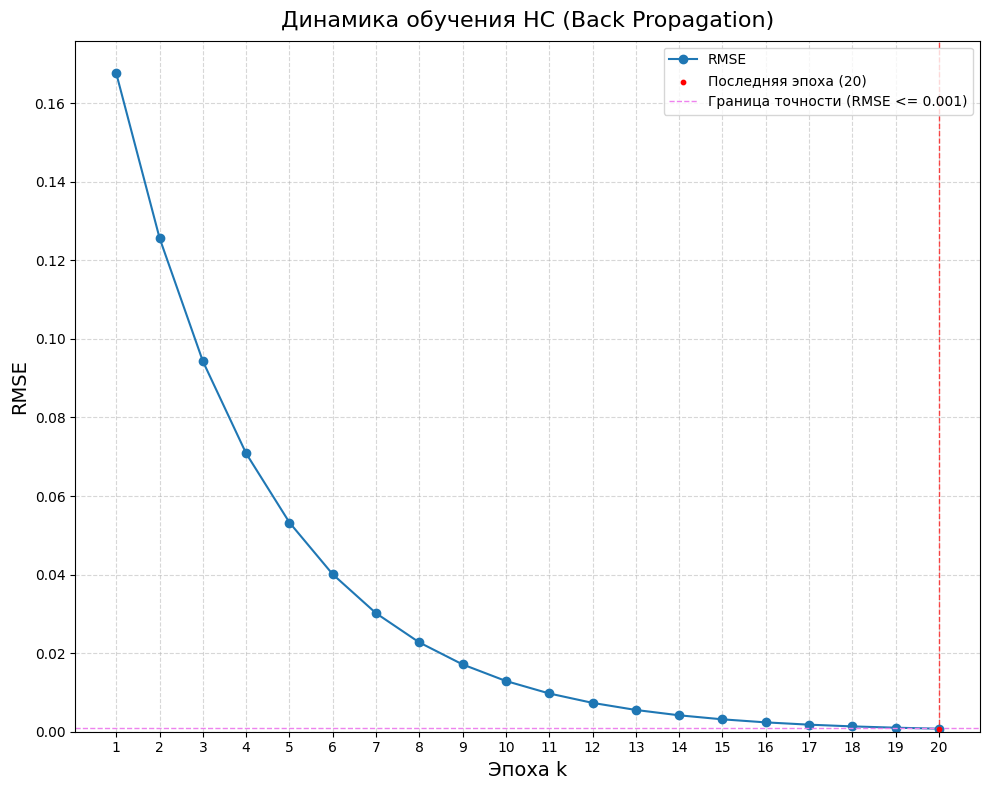

In [495]:
weight_results = back_propagation_neuron.get_weights_history()
back_propagation_neuron.print_training_info(X_train)
print(weight_results)
output_df = back_propagation_neuron.get_outputs_table()
print(output_df)
get_plot(back_propagation_neuron.delta_history, back_propagation_neuron.eps)